# Universe method

by Reece Colclough and Oleg Glotov

In [54]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sbn

#used to check for stationarity in the time series
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import linregress

# ignore warnings for the KPSS test 
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

In order to find the best stationarity pair, we need to utilize both the ADF test and the KPSS test. Both tests have their drawback and potential issue, therefore, a pair of stocks that performs well in both tests are likely to be more stationary. We construct this test statistic in the following way:
$$\text{Stationarity Score} = - \text{KPSS Stats} - \text{ADF Test}$$
since a low KPSS stats and a low ADF stats both indicates stronger evidence of stationarity (how we weight these two stats is subjective to improvement)

In [55]:
def check_stationarity(series, alpha):

    # h_0 is that the series has a unit root-> if so, likely non-stationarity
    result_adf = adfuller(series,regression='ct')
    p_val = result_adf[1]
    if p_val < alpha:
        # reject, likely trend stationary
        print("ADF test: p-val=", p_val, "-> Conclusion: likely trend stationary")
    else:
        print("ADF test: p-val=", p_val, "-> Conclusion: likely non-stationarity")

    #return result_adf[1]

     #print("----------------------------------------------------------------")
    
    # Since we are focusing on the trend stationarity, we will use the KPSS test
    result_kpss = kpss(series, regression='ct')
    kpss_stat = result_kpss[0]
    p_val = result_kpss[1]
    if p_val > alpha:
        #reject, likely stationary
        print("KPSS test: KPSS stats:", kpss_stat, "p-val=", p_val, "-> Conclusion: likely trend stationary")
    else:
        print("KPSS test: KPSS stats:", kpss_stat, "p-val=", p_val, "-> Conclusion: likely not trend stationary")
    
    station_score = -kpss_stat - result_adf[0]
    return station_score


In [56]:
def methodology_cointegration(stk1, stk2):
    diff = abs(stk1["Close"] - stk2["Close"])

    time = np.arange(len(diff))
    reg = linregress(time, diff)
    #line = reg.intercept + reg.slope*time
    #new_series = diff - line

    return check_stationarity(diff, 0.05), reg.slope


def methodology(stk1, stk2):
    # Calculate correlation between the two stocks' adjusted close prices
    correlation = np.corrcoef(stk1["Close"], stk2["Close"])[0,1]
    
    # Calculate the slope between the two stocks
    time = np.arange(len(stk1["Close"]))
    reg = linregress(time, stk2["Close"] - stk1["Close"])
    
    return correlation, reg.slope

In [57]:
def download_data(stk):

    # start date because of moderna listing in 2018 December and yfinance data delay

    start_date = "2024-01-16"
    end_date = "2025-01-15"

    stk_data = yf.download(stk,start=start_date,end=end_date)

    # fix
    stk_data.columns = stk_data.columns.get_level_values(0)

    return stk_data

In [58]:
# Will plot 2 equities

# universe = ["MSFT", "MRNA",]

# stk_data = []
# for stk in universe:
#     stk_data.append(download_data(stk))

# plt.figure()
# for x in stk_data:
#     plt.plot(x["Close"], label="stk1")

# plt.legend()
# plt.title("stks Price Plot")
# plt.show()

In [59]:
# Download Data

universe = ["AAPL","AAL","AMD","AMZN","BA","BABA","BAC","C","CAT","COST","CSCO","CVX","DIS","DLR","EQIX","F","GM","GOOGL","GS","IBM","INTC","JNJ","JPM","KO","LMT","LULU","META","MPC","MRK","MRNA","MSFT","MU","NFLX","NKE","NVDA","PFE","TSLA","VZ","WFC","WM","XOM","SCHW","RIOT",]

stk_data = []
for stk in universe:
    stk_data.append(download_data(stk))

# Align all dataframes on their index
aligned_data = []
for df in stk_data:
    # Reset index to make date a column
    df_reset = df.reset_index()
    aligned_data.append(df_reset)

# Find common dates across all dataframes
common_dates = set(aligned_data[0]['Date'])
for df in aligned_data[1:]:
    common_dates = common_dates.intersection(set(df['Date']))

# Filter each dataframe to only include common dates
filtered_data = []
for df in aligned_data:
    filtered = df[df['Date'].isin(common_dates)].sort_values('Date').set_index('Date')
    filtered_data.append(filtered)

stk_data = filtered_data  # Replace original data with aligned data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [60]:
# normalize the stock price for all the stocks so that the first date's price is 1

for i in range(len(stk_data)):
    stk_data[i]["Close"] = stk_data[i]["Close"]/stk_data[i]["Close"][0]

/var/folders/ty/5gy6m3k52ps97ms9_x3glvnh0000gn/T/ipykernel_48885/3837039736.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  stk_data[i]["Close"] = stk_data[i]["Close"]/stk_data[i]["Close"][0]


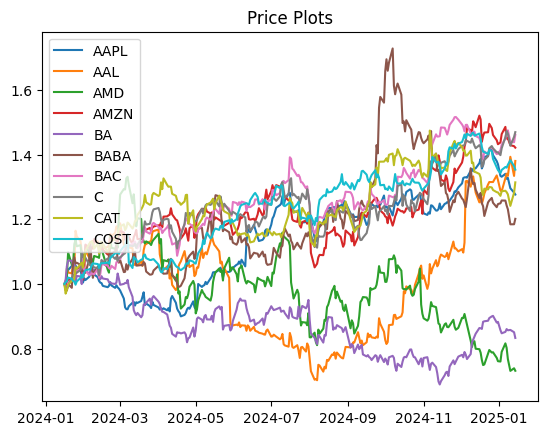

In [61]:
plt.figure()
i = 0
for x in stk_data[:10]:
    plt.plot(x["Close"], label=universe[i])
    i+=1

plt.legend()
plt.title("Price Plots")
plt.savefig('Stock Prices.png', dpi = 1500)
# plt.show()

In [62]:
# initialize cov-matrix
data = np.random.rand(len(universe), len(universe))
slope = np.random.rand(len(universe), len(universe))
stockNum = len(universe)


# Calculate the stationary properties
cov = np.zeros((stockNum, stockNum))
for i in range(stockNum):
    for j in range(stockNum):
        if (i == j):
            data[i,j] = 1
            # set the slope to 0 if the stock is the same
            slope[i,j] = 0
        else:
            print(universe[i]+universe[j])
            
            data[i,j],slope[i,j] = methodology_cointegration(stk_data[i],stk_data[j])

AAPLAAL
ADF test: p-val= 0.7726067779594366 -> Conclusion: likely non-stationarity
KPSS test: KPSS stats: 0.44179851913580714 p-val= 0.01 -> Conclusion: likely not trend stationary
AAPLAMD
ADF test: p-val= 0.527636196860674 -> Conclusion: likely non-stationarity
KPSS test: KPSS stats: 0.23118614688286854 p-val= 0.01 -> Conclusion: likely not trend stationary
AAPLAMZN
ADF test: p-val= 0.38597928192632186 -> Conclusion: likely non-stationarity
KPSS test: KPSS stats: 0.22062352315944145 p-val= 0.01 -> Conclusion: likely not trend stationary
AAPLBA
ADF test: p-val= 0.3342817945373506 -> Conclusion: likely non-stationarity
KPSS test: KPSS stats: 0.26687977810702984 p-val= 0.01 -> Conclusion: likely not trend stationary
AAPLBABA
ADF test: p-val= 0.012041781527084664 -> Conclusion: likely trend stationary
KPSS test: KPSS stats: 0.07920100255515097 p-val= 0.1 -> Conclusion: likely trend stationary
AAPLBAC
ADF test: p-val= 0.4180553449629462 -> Conclusion: likely non-stationarity
KPSS test: KPS

In [63]:
# Create a heatmap of slope using Matplotlib
plt.figure(figsize=(stockNum, stockNum),dpi=250)
heat_map_slope = sbn.heatmap(slope, xticklabels=universe, yticklabels=universe, annot=True, cmap="mako")
plt.title("Heat Map of Slope for Cointegration Pairs")

plt.savefig('HeatMap_Cointegration_slope.png')
plt.show()

In [64]:
# Create a heatmap using Matplotlib
plt.figure(figsize=(stockNum, stockNum),dpi=250)
heat_map = sbn.heatmap(data, xticklabels=universe, yticklabels=universe, annot=True, cmap="mako")
plt.title("Heat Map of Cointegration Scores for Pairs")

plt.savefig('HeatMap_Cointegration_score.png')
plt.show()

In [65]:
df = pd.DataFrame(data = data)
df.columns = universe

print("Data Frame")
print(df)
print()

# Get data below diagonal and sort
sol = (df.where(np.triu(np.ones(df.shape), k=1).astype(bool)).stack().sort_values(ascending=False).reset_index())

mapping = {i: universe[i] for i in range(len(universe))}

# Replace numbers in column 'A' with the corresponding index string
sol['level_0'] = sol['level_0'].map(mapping)

Data Frame
        AAPL       AAL       AMD      AMZN        BA      BABA       BAC  \
0   1.000000  1.207334  1.901705  2.167448  2.220537  3.823178  2.132404   
1   1.207334  1.000000  1.354834  0.720980  1.168700  0.967765  0.195005   
2   1.901705  1.354834  1.000000  1.704348  3.180991  2.782315  2.551892   
3   2.167448  0.720980  1.704348  1.000000  2.167074  3.210030  4.331068   
4   2.220537  1.168700  3.180991  2.167074  1.000000  1.145897  2.457017   
5   3.823178  0.967765  2.782315  3.210030  1.145897  1.000000  4.191413   
6   2.132404  0.195005  2.551892  4.331068  2.457017  4.191413  1.000000   
7   1.984210  0.669291  1.895656  5.534974  2.759320  3.090853  3.382145   
8   1.971912  0.642786  2.850088  4.077206  1.713570  3.128412  3.194676   
9   3.168053  0.058262  2.858045  3.389609  1.949324  3.991395  3.576069   
10  0.982117  3.533669  1.250287  2.498435  1.472308  1.576268  1.726597   
11  2.423061  2.102647  2.459465  2.662397  2.503006  1.885231  4.173402   
1

In [66]:
print(sol)
print()
n = 30
print(f"last {n} rows")
print()
print(sol.tail(n))

    level_0 level_1         0
0      AMZN       C  5.534974
1      BABA     JPM  5.475870
2        GM     WFC  5.141564
3       AAL    RIOT  4.820635
4       WFC    RIOT  4.792916
..      ...     ...       ...
898    COST    LULU -0.290563
899     LMT    LULU -0.469655
900      KO    LULU -0.483853
901     JNJ    LULU -0.497908
902    AAPL    LULU -0.539610

[903 rows x 3 columns]

last 30 rows

    level_0 level_1         0
873     IBM    LULU  0.564451
874     AAL      WM  0.544009
875       C     XOM  0.530682
876     DLR    LULU  0.524151
877    EQIX    LULU  0.458943
878    LULU     MRK  0.454770
879     AAL     JPM  0.449261
880     CVX     XOM  0.445765
881      GS    LULU  0.399520
882    LULU      WM  0.369461
883   GOOGL    LULU  0.367989
884     AAL      GS  0.333432
885     AMD    TSLA  0.323134
886    AMZN    MSFT  0.318197
887     AAL     BAC  0.195005
888    LULU     XOM  0.178446
889     AAL      GM  0.145715
890    BABA    LULU  0.100043
891     AAL     IBM  0.072581
8

In [67]:
# add a new column to the dataframe
sol['slope'] = sol.apply(lambda row: slope[universe.index(row['level_0'])][universe.index(row['level_1'])], axis=1)
sol.columns = ['Stock 1', 'Stock 2', 'Stationarity Score', 'Slope']
# display the top 30 pairs with positive slope
print()
print("Top 30 Pairs with Positive Slope")
print()
print(sol[sol['Slope'] > 0].head(30))


Top 30 Pairs with Positive Slope

   Stock 1 Stock 2  Stationarity Score     Slope
0     AMZN       C            5.534974  0.000059
1     BABA     JPM            5.475870  0.000738
2       GM     WFC            5.141564  0.000181
3      AAL    RIOT            4.820635  0.000185
4      WFC    RIOT            4.792916  0.001698
5     BABA      GS            4.713420  0.001094
6      CVX      GM            4.686918  0.001753
7      MRK    RIOT            4.681732  0.000338
8      BAC      GM            4.663445  0.000161
9        F      VZ            4.640482  0.000345
10     AMD    RIOT            4.623686  0.000451
11    BABA      GM            4.561755  0.000623
13     DLR    SCHW            4.366308  0.000429
14    AMZN     BAC            4.331068  0.000208
15       F    MSFT            4.270911  0.000413
16     AMD       F            4.262132  0.000138
17       F      WM            4.230552  0.001012
19    BABA     BAC            4.191413  0.000642
20    LULU    RIOT            4.18